In [291]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error
mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False

In [292]:
data = pd.read_excel("df.xlsx")

# Remove unwanted rows
df = data.iloc[27:, :]

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort values by date
df = df.sort_values('Date')


df.head()

,Date,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
27,1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
28,1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
29,1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63
30,1993-09-01,1994,Maha,262421,149356,169287,581064,250482,145815,164396,...,23.46,76.54,0.0,0.0,0.0,0.0,0.0,87.39,3.44,9.17
31,1994-04-01,1994,Yala,207466,63284,77806,348556,206527,58869,70462,...,19.81,80.19,0.0,0.0,0.0,0.0,0.0,92.78,1.28,5.93


In [293]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

In [294]:
df = df[['Date','Chemical_only', 'Organic_only', 'Both',
       'None']]
df.shape

(67, 5)

In [295]:
# Set Date as index
df.set_index('Date', inplace=True)
df.head()

,Chemical_only,Organic_only,Both,None
Date,,,,
1992-04-01,92.75,0.73,2.31,4.21
1992-09-01,91.70,1.31,2.13,4.85
1993-04-01,91.49,0.37,3.87,4.27
1993-09-01,90.14,0.79,3.59,5.48
1994-04-01,91.50,0.85,3.86,3.79


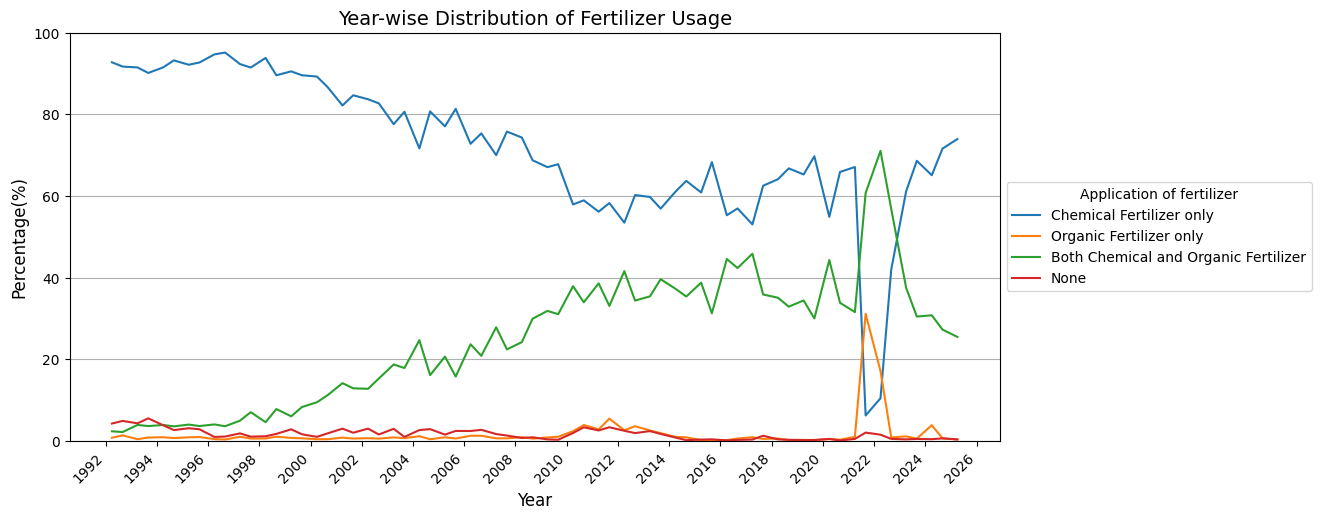

In [296]:
ax = df.plot(figsize=(12,6))

ax.xaxis.set_major_locator(mdates.YearLocator(2))       # tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year
ax.set_ylim(0,100)
plt.xticks(rotation=45)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage(%)", fontsize=12)
plt.legend(["Chemical Fertilizer only","Organic Fertilizer only","Both Chemical and Organic Fertilizer","None"], title= "Application of fertilizer",loc="center left",
           bbox_to_anchor=(1, 0.5))
plt.title("Year-wise Distribution of Fertilizer Usage", fontsize=14)
plt.grid(axis='y')
plt.show()

In [297]:
# =========================================================
# ADF TEST FUNCTION
# =========================================================

def adf_check(series):

    result = adfuller(series.dropna())

    return result[0], result[1]


In [298]:
# =========================================================
# CHECK ORIGINAL STATIONARITY
# =========================================================

print("\nADF TEST RESULTS (ORIGINAL SERIES)")

diff_count = {}

for column in df.columns:

    adf_stat, p_value = adf_check(df[column])

    print(f"\n{column}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")

    d = 0
    temp_series = df[column].copy()

    while adf_check(temp_series)[1] > 0.05:

        temp_series = temp_series.diff().dropna()

        d += 1

        if d == 3:
            break

    diff_count[column] = d

    print(f"Differencing Needed : {d}")


ADF TEST RESULTS (ORIGINAL SERIES)

Chemical_only
ADF Statistic : -0.8365
p-value       : 0.8082
Differencing Needed : 2

Organic_only
ADF Statistic : -5.3511
p-value       : 0.0000
Differencing Needed : 0

Both
ADF Statistic : -1.4490
p-value       : 0.5586
Differencing Needed : 2

None
ADF Statistic : -3.2007
p-value       : 0.0199
Differencing Needed : 0


In [299]:

# =========================================================
# USE SAME DIFFERENCING ORDER FOR ALL SERIES
# =========================================================

max_diff = max(diff_count.values())

print("\nMaximum Differencing Order Used :", max_diff)

# =========================================================
# DIFFERENCE ALL SERIES EQUALLY
# =========================================================

df_diff = df.copy()

for i in range(max_diff):

    df_diff = df_diff.diff()

df_diff = df_diff.dropna()


Maximum Differencing Order Used : 2


In [302]:
df_diff.shape

(65, 4)

In [303]:
# =========================================================
# FINAL STATIONARITY TEST
# =========================================================

print("\nFINAL STATIONARITY RESULTS")

for column in df_diff.columns:

    adf_stat, p_value = adf_check(df_diff[column])

    print(f"\n{column}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")

    if p_value <= 0.05:
        print("Series is Stationary")

    else:
        print("Series is STILL NOT Stationary")


FINAL STATIONARITY RESULTS

Chemical_only
ADF Statistic : -6.8817
p-value       : 0.0000
Series is Stationary

Organic_only
ADF Statistic : -5.1534
p-value       : 0.0000
Series is Stationary

Both
ADF Statistic : -5.0812
p-value       : 0.0000
Series is Stationary

None
ADF Statistic : -7.4151
p-value       : 0.0000
Series is Stationary


In [304]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_size = int(len(df_diff) * 0.8)

train = df_diff.iloc[:train_size]
test = df_diff.iloc[train_size:]

print("\nTrain Shape :", train.shape)
print("Test Shape  :", test.shape)


Train Shape : (52, 4)
Test Shape  : (13, 4)


In [305]:
# =========================================================
# FIT VAR MODEL
# =========================================================

model = VAR(train)

lag_selection = model.select_order(maxlags=8)

print("\nLAG SELECTION")
print(lag_selection.summary())

optimal_lag = lag_selection.aic

if optimal_lag is None:
    optimal_lag = 1

print("\nOptimal Lag :", optimal_lag)

# fit VAR
var_model = model.fit(optimal_lag)

print(var_model.summary())


LAG SELECTION
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -2.962      -2.800     0.05172      -2.902
1      -5.992      -5.181    0.002509      -5.691
2      -7.297     -5.837*   0.0006938      -6.755
3      -7.198      -5.089   0.0008046      -6.416
4      -7.167      -4.410   0.0009137      -6.145
5      -7.735      -4.328   0.0006130      -6.471
6      -7.926      -3.871   0.0006671      -6.422
7      -8.103      -3.400   0.0008705      -6.359
8     -9.945*      -4.593  0.0002854*     -7.960*
-------------------------------------------------

Optimal Lag : 8
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 28, May, 2026
Time:                     20:07:54
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -4.59287
Nobs:

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [306]:
# =========================================================
# FORECASTING
# =========================================================

forecast_input = train.values[-optimal_lag:]

forecast = var_model.forecast(
    y=forecast_input,
    steps=len(test)
)

forecast_diff = pd.DataFrame(
    forecast,
    index=test.index,
    columns=test.columns
)

print("\nForecast Values (Differenced Scale)")
print(forecast_diff.head())


Forecast Values (Differenced Scale)
            Chemical_only  Organic_only       Both      None
Date                                                        
2019-04-01      -9.142917     -0.397295  10.134920 -0.582338
2019-09-01      19.243111     -0.473212 -17.850844 -0.914826
2020-04-01     -14.871325      0.054932  13.867631  0.957502
2020-09-01       7.950270      1.083778  -9.970822  0.911364
2021-04-01      -9.767819     -0.682782  11.505983 -1.043769


In [307]:
# =========================================================
# INVERSE DIFFERENCING
# =========================================================

forecast_lvl1 = forecast_diff.cumsum() + train.diff().iloc[-1]

forecast_original = (
    forecast_lvl1.cumsum()
    + df.iloc[train_size + max_diff - 1]
)

print("\nForecast Values (Original Scale)")
print(forecast_original.head())


Forecast Values (Original Scale)
            Chemical_only  Organic_only       Both       None
Date                                                         
2019-04-01      66.537083     -1.207295  32.424920   2.237662
2019-09-01      85.567277     -3.057803  14.138996   3.340498
2020-04-01      89.726146     -4.853378   9.720703   5.400836
2020-09-01     101.835285     -5.565176  -4.668412   8.372538
2021-04-01     104.176605     -6.959755  -7.551545  10.300470


In [308]:
# =========================================================
# ACTUAL VALUES
# =========================================================

actual = df.iloc[train_size + max_diff:]

# align indexes
forecast_original = forecast_original.loc[actual.index]


In [309]:
forecast_original

,Chemical_only,Organic_only,Both,None
Date,,,,
2019-04-01,66.537083,-1.207295,32.424920,2.237662
2019-09-01,85.567277,-3.057803,14.138996,3.340498
2020-04-01,89.726146,-4.853378,9.720703,5.400836
2020-09-01,101.835285,-5.565176,-4.668412,8.372538
2021-04-01,104.176605,-6.959755,-7.551545,10.300470
2021-09-01,115.032088,-6.809233,-21.434923,13.157477
2022-04-01,116.575274,-8.997176,-22.745160,15.117080
2022-09-01,129.231784,-8.529682,-38.328666,17.565573
2023-04-01,126.626324,-9.507412,-38.093301,20.904929


In [310]:
# =========================================================
# MODEL EVALUATION
# =========================================================

print("\nMODEL EVALUATION")

for column in df.columns:

    mae = mean_absolute_error(
        actual[column],
        forecast_original[column]
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual[column],
            forecast_original[column]
        )
    )

    mape = np.mean(
        np.abs(
            (actual[column] - forecast_original[column])
            / (actual[column] + 1e-10)
        )
    ) * 100

    print(f"\n{column}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")


MODEL EVALUATION

Chemical_only
MAE  : 62.2761
RMSE : 70.4536
MAPE : 288.17%

Organic_only
MAE  : 11.9588
RMSE : 15.3058
MAPE : 1418.45%

Both
MAE  : 65.8443
RMSE : 73.9691
MAPE : 181.68%

None
MAE  : 15.4724
RMSE : 18.1769
MAPE : 4513.86%


In [311]:
# =========================================================
# STABILITY CHECK
# =========================================================

print("\nIs VAR Model Stable?")
print(var_model.is_stable())


Is VAR Model Stable?
False


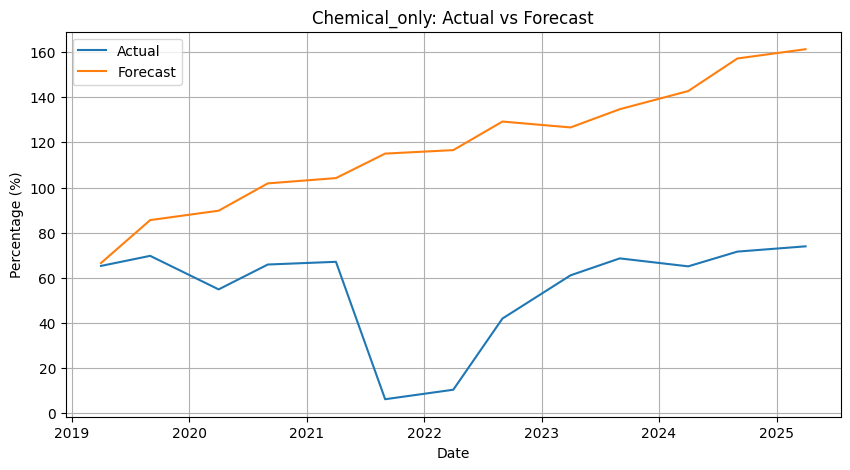

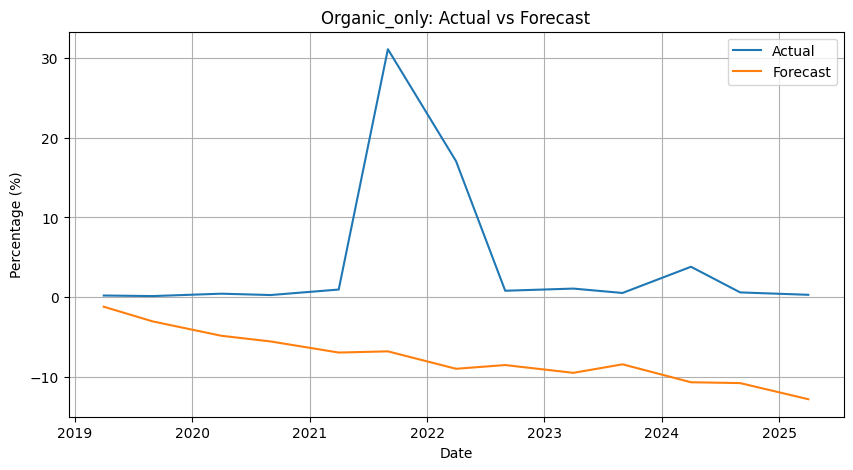

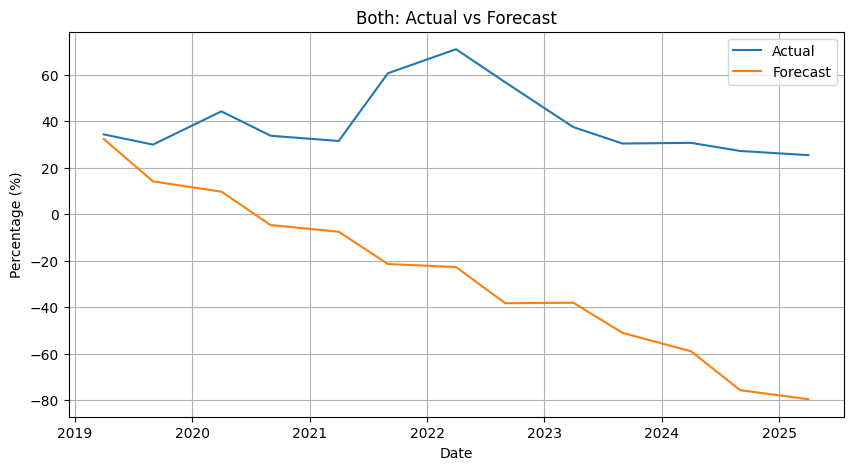

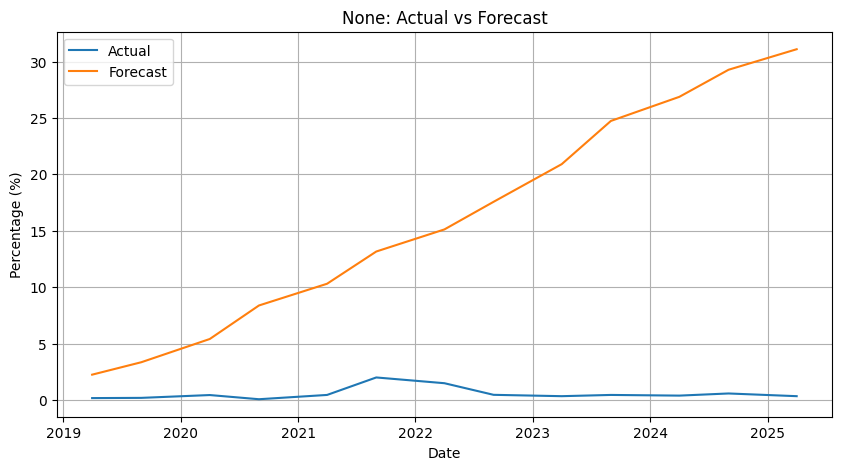

In [312]:
# =========================================================
# ACTUAL VS FORECAST PLOTS
# =========================================================

for column in df.columns:

    plt.figure(figsize=(10,5))

    plt.plot(
        actual.index,
        actual[column],
        label='Actual'
    )

    plt.plot(
        forecast_original.index,
        forecast_original[column],
        label='Forecast'
    )

    plt.title(f'{column}: Actual vs Forecast')

    plt.xlabel("Date")
    plt.ylabel("Percentage (%)")

    plt.legend()

    plt.grid(True)

    plt.show()